# Growth-Geometry Split notebook for $\Omega_m$

This notebook works with the `cloelib` branch `346-omegam-split-ODE-growth-rescale-power-spectrum` . The plots show the validation with the CosmoSIS implementation but work only if one has the pickle outputs. That is why they are commented out.

In [1]:
import numpy as np
# import pickle
import matplotlib.pyplot as plt
from scipy import interpolate
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations 
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.derived_cosmology import (
    growth_function_ODE,
    SplitLinearPerturbations,
    SplitNonLinearPerturbations,
)

In [2]:
# Cosmology parameters
H0 = 67.7
h = H0 / 100.0
sigma8 = 0.8277
Omega_b0 = 0.048
Omega_m = 0.3
Omega_cdm0 = Omega_m - Omega_b0
Omega_k0 = 0.0
w = -1.0
wa = 0.0
ns = 0.96
mnu = 0.0
As = 2e-9
gamma_MG = 0.0

z = np.linspace(0, 3, 100)
# Compute the background with CAMB
camb_instance = CAMBBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_mnu=0,
)
camb_instance = CAMBBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_mnu=0,
)

## Differential Equation for the Growth G(z)

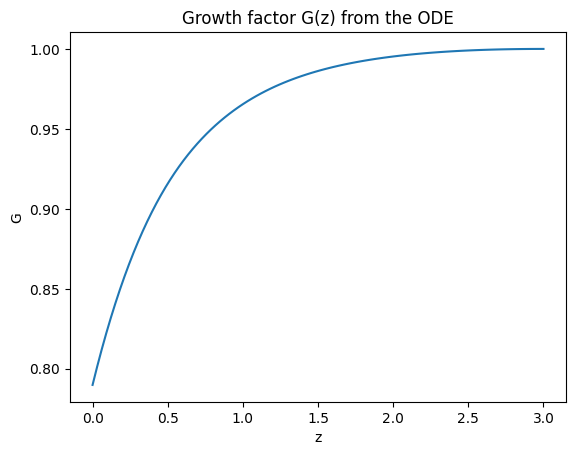

In [3]:
# Test the differential equation for the growth G(z)
g_z_geo = growth_function_ODE(camb_instance, z)
plt.clf()
plt.plot(z, g_z_geo)
plt.xlabel("z")
plt.ylabel("G")
plt.title("Growth factor G(z) from the ODE")
plt.show()

## Rescaled Matter Power Spectrum CAMB
Plots show the CosmoSIS Validation where we implemented the growth-geometry split. This only works with the pickle files from CosmoSIS.

In [4]:
ks = np.logspace(np.log10(1e-5), np.log10(1e0), 200)

camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=z, nonlinear_model="halofit16")

# Compute the split MPS for 5 combinations of values for Omega_m^geo and
# Omega_m^growth: here Omega_m^geo = 0.3, Omega_m^growth = 0.3

split_linear_3_3 = SplitLinearPerturbations(
    background=camb_instance, omega_m_growth=0.3, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_3_3, linear_pk_3_3 = split_linear_3_3.matter_power_spectrum(z, ks)
split_nonlinear_3_3 = SplitNonLinearPerturbations(
    background=camb_instance,
    omega_m_growth=0.25,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_3_3,
    pk_linear=linear_pk_3_3,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit16",
)
nonlinear_pk_3_3 = split_nonlinear_3_3.matter_power_spectrum(z, ks)
nl_pk_3_3_interp = interpolate.interp1d(ks, nonlinear_pk_3_3[0, :])

# Omega_m^geo = 0.3, Omega_m^growth = 0.25

split_linear_3_25 = SplitLinearPerturbations(
    background=camb_instance, omega_m_growth=0.25, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_3_25, linear_pk_3_25 = split_linear_3_25.matter_power_spectrum(z, ks)
split_nonlinear_3_25 = SplitNonLinearPerturbations(
    background=camb_instance,
    omega_m_growth=0.25,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_3_25,
    pk_linear=linear_pk_3_25,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit16",
)
nonlinear_pk_3_25 = split_nonlinear_3_25.matter_power_spectrum(z, ks)
nl_pk_3_25_interp = interpolate.interp1d(ks, nonlinear_pk_3_25[0, :])

# Omega_m^geo = 0.3, Omega_m^growth = 0.35

split_linear_3_35 = SplitLinearPerturbations(
    background=camb_instance, omega_m_growth=0.35, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_3_35, linear_pk_3_35 = split_linear_3_35.matter_power_spectrum(z, ks)
split_nonlinear_3_35 = SplitNonLinearPerturbations(
    background=camb_instance,
    omega_m_growth=0.35,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_3_35,
    pk_linear=linear_pk_3_35,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit",
)
nonlinear_pk_3_35 = split_nonlinear_3_35.matter_power_spectrum(z, ks)
nl_pk_3_35_interp = interpolate.interp1d(ks, nonlinear_pk_3_35[0, :])

# Omega_m^geo = 0.25, Omega_m^growth = 0.3

Omega_m = 0.25
Omega_m_growth = 0.3
Omega_cdm0 = Omega_m - Omega_b0
camb_instance_25 = CAMBBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_mnu=0,
)

camb_linear = CAMBLinearPerturbations(background=camb_instance_25, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance_25, redshifts=z, nonlinear_model="halofit")
split_linear_25_3 = SplitLinearPerturbations(
    background=camb_instance_25, omega_m_growth=Omega_m_growth, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_25_3, linear_pk_25_3 = split_linear_25_3.matter_power_spectrum(z, ks)
split_nonlinear_25_3 = SplitNonLinearPerturbations(
    background=camb_instance_25,
    omega_m_growth=Omega_m_growth,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_25_3,
    pk_linear=linear_pk_25_3,
    perturbations=camb_nonlinear
    # nonlinear_model="halofit",
)
nonlinear_pk_25_3 = split_nonlinear_25_3.matter_power_spectrum(z, ks)
nl_pk_25_3_interp = interpolate.interp1d(ks, nonlinear_pk_25_3[0, :])

# Omega_m^geo = 0.35, Omega_m^growth = 0.3

Omega_m = 0.35
Omega_m_growth = 0.3
Omega_cdm0 = Omega_m - Omega_b0
camb_instance_35 = CAMBBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_mnu=0,
)
camb_linear = CAMBLinearPerturbations(background=camb_instance_35, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance_35, redshifts=z, nonlinear_model="halofit")
split_linear_35_3 = SplitLinearPerturbations(
    background=camb_instance_35, omega_m_growth=Omega_m_growth, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_35_3, linear_pk_35_3 = split_linear_35_3.matter_power_spectrum(z, ks)
split_nonlinear_35_3 = SplitNonLinearPerturbations(
    background=camb_instance_35,
    omega_m_growth=Omega_m_growth,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_35_3,
    pk_linear=linear_pk_35_3,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit",
)
nonlinear_pk_35_3 = split_nonlinear_35_3.matter_power_spectrum(z, ks)
nl_pk_35_3_interp = interpolate.interp1d(ks, nonlinear_pk_35_3[0, :])

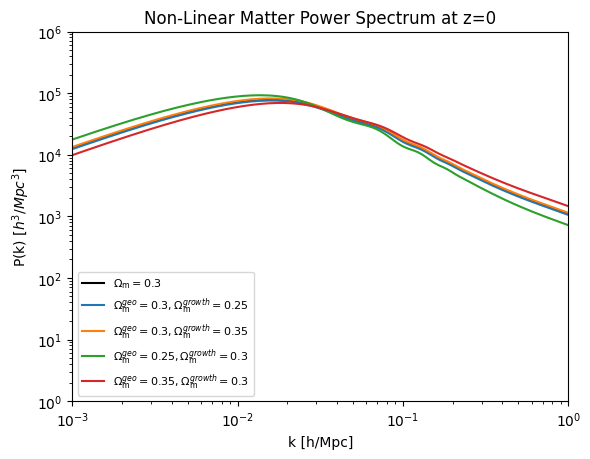

<Figure size 640x480 with 0 Axes>

In [5]:
# This can import the CosmoSIS pickles for the validation

# with open("mps_k_h.pkl", "rb") as in_pkl:
#     k_h = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-03_comp.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_03 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-03-om-growth-025_comp.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_025 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-03-om-growth-035_comp.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_035 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-025-om-growth-03_comp.pkl", "rb") as in_pkl:
#     mps_geo_025_gr_03 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-035-om-growth-03_comp.pkl", "rb") as in_pkl:
#     mps_geo_035_gr_03 = pickle.load(in_pkl) / h ** 3

plt.loglog(ks / h, nl_pk_3_3_interp(ks), color="black",
           label="$\\Omega_{\\rm m}=0.3$")
plt.loglog(ks / h, nl_pk_3_25_interp(ks),
           label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$")
plt.loglog(ks / h, nl_pk_3_35_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$")
plt.loglog(ks / h, nl_pk_25_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.3$")
plt.loglog(ks / h, nl_pk_35_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.3$")

# plt.plot(k_h, mps_geo_03_gr_03[0, :], label="$CS:\\Omega_{\\rm m}=0.3$",
#         color="grey", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_025[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3,\\Omega^{growth}_{\\rm m}=0.25$",
#         color="red", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_035[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3,\\Omega^{growth}_{\\rm m}=0.35$",
#         color="black", linestyle='--')
# plt.plot(k_h, mps_geo_025_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.3$",
#         color="orange", linestyle='--')
# plt.plot(k_h, mps_geo_035_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.3$",
#         color="purple", linestyle='--')

plt.xlabel("k [h/Mpc]")
plt.ylabel(r"P(k) [$h^3/Mpc^3$]")
plt.xlim(1e-3, 1e0)
plt.ylim(1e0, 1e6)
plt.title("Non-Linear Matter Power Spectrum at z=0")
plt.legend(fontsize=8)
plt.show()
plt.clf()

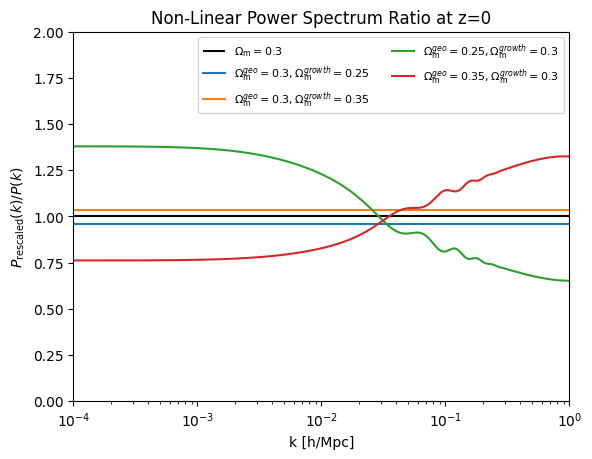

<Figure size 640x480 with 0 Axes>

In [6]:
# Plot the ratio of the rescaled and the standard MPS

plt.hlines(1, np.min(ks), np.max(ks), label="$\\Omega_{\\rm m}=0.3$",
           color="black")
plt.plot(ks / h, nl_pk_3_25_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$")
plt.plot(ks / h, nl_pk_3_35_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$")
plt.plot(ks / h, nl_pk_25_3_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.3$")
plt.plot(ks / h, nl_pk_35_3_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.3$")

# plt.plot(k_h, mps_geo_03_gr_025[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$",
#         color="red", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_035[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$",
#         color="black", linestyle='--')
# plt.plot(k_h, mps_geo_025_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.3$",
#         color="orange", linestyle='--')
# plt.plot(k_h, mps_geo_035_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.3$",
#         color="purple", linestyle='--')

plt.title("Non-Linear Power Spectrum Ratio at z=0")
plt.xlabel("k [h/Mpc]")
plt.ylabel("$P_{\\rm rescaled}(k)/P(k)$")
plt.xscale("log")
plt.xlim(1e-4, 1e0)
plt.ylim(0, 2)
plt.legend(ncol=2, fontsize=8)
plt.show()
plt.clf()

## Rescaled Matter Power Spectrum CAMB
Plots show the CosmoSIS Validation where we implemented the growth-geometry split. This only works with the pickle files from CosmoSIS.

In [10]:
ks = np.logspace(np.log10(1e-5), np.log10(1e0), 200)

camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=z)

# Compute the split MPS for 5 combinations of values for Omega_m^geo and
# Omega_m^growth: here Omega_m^geo = 0.3, Omega_m^growth = 0.3

split_linear_3_3 = SplitLinearPerturbations(
    background=camb_instance, omega_m_growth=0.3, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_3_3, linear_pk_3_3 = split_linear_3_3.matter_power_spectrum(z, ks)
split_nonlinear_3_3 = SplitNonLinearPerturbations(
    background=camb_instance,
    omega_m_growth=0.25,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_3_3,
    pk_linear=linear_pk_3_3,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit16",
)
nonlinear_pk_3_3 = split_nonlinear_3_3.matter_power_spectrum(z, ks)
nl_pk_3_3_interp = interpolate.interp1d(ks, nonlinear_pk_3_3[0, :])

# Omega_m^geo = 0.3, Omega_m^growth = 0.25

split_linear_3_25 = SplitLinearPerturbations(
    background=camb_instance, omega_m_growth=0.25, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_3_25, linear_pk_3_25 = split_linear_3_25.matter_power_spectrum(z, ks)
split_nonlinear_3_25 = SplitNonLinearPerturbations(
    background=camb_instance,
    omega_m_growth=0.25,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_3_25,
    pk_linear=linear_pk_3_25,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit16",
)
nonlinear_pk_3_25 = split_nonlinear_3_25.matter_power_spectrum(z, ks)
nl_pk_3_25_interp = interpolate.interp1d(ks, nonlinear_pk_3_25[0, :])

# Omega_m^geo = 0.3, Omega_m^growth = 0.35

split_linear_3_35 = SplitLinearPerturbations(
    background=camb_instance, omega_m_growth=0.35, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_3_35, linear_pk_3_35 = split_linear_3_35.matter_power_spectrum(z, ks)
split_nonlinear_3_35 = SplitNonLinearPerturbations(
    background=camb_instance,
    omega_m_growth=0.35,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_3_35,
    pk_linear=linear_pk_3_35,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit",
)
nonlinear_pk_3_35 = split_nonlinear_3_35.matter_power_spectrum(z, ks)
nl_pk_3_35_interp = interpolate.interp1d(ks, nonlinear_pk_3_35[0, :])

# Omega_m^geo = 0.25, Omega_m^growth = 0.3

Omega_m = 0.25
Omega_m_growth = 0.3
Omega_cdm0 = Omega_m - Omega_b0
camb_instance_25 = CAMBBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_mnu=0,
)

camb_linear = CAMBLinearPerturbations(background=camb_instance_25, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance_25, redshifts=z)
split_linear_25_3 = SplitLinearPerturbations(
    background=camb_instance_25, omega_m_growth=Omega_m_growth, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_25_3, linear_pk_25_3 = split_linear_25_3.matter_power_spectrum(z, ks)
split_nonlinear_25_3 = SplitNonLinearPerturbations(
    background=camb_instance_25,
    omega_m_growth=Omega_m_growth,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_25_3,
    pk_linear=linear_pk_25_3,
    perturbations=camb_nonlinear
    # nonlinear_model="halofit",
)
nonlinear_pk_25_3 = split_nonlinear_25_3.matter_power_spectrum(z, ks)
nl_pk_25_3_interp = interpolate.interp1d(ks, nonlinear_pk_25_3[0, :])

# Omega_m^geo = 0.35, Omega_m^growth = 0.3

Omega_m = 0.35
Omega_m_growth = 0.3
Omega_cdm0 = Omega_m - Omega_b0
camb_instance_35 = CAMBBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_mnu=0,
)
camb_linear = CAMBLinearPerturbations(background=camb_instance_35, redshifts=z)
camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance_35, redshifts=z)
split_linear_35_3 = SplitLinearPerturbations(
    background=camb_instance_35, omega_m_growth=Omega_m_growth, redshifts=z, perturbations=camb_linear
)
linear_pk_camb_35_3, linear_pk_35_3 = split_linear_35_3.matter_power_spectrum(z, ks)
split_nonlinear_35_3 = SplitNonLinearPerturbations(
    background=camb_instance_35,
    omega_m_growth=Omega_m_growth,
    redshifts=z,
    pk_linear_EBS=linear_pk_camb_35_3,
    pk_linear=linear_pk_35_3,
    perturbations=camb_nonlinear,
    # nonlinear_model="halofit",
)
nonlinear_pk_35_3 = split_nonlinear_35_3.matter_power_spectrum(z, ks)
nl_pk_35_3_interp = interpolate.interp1d(ks, nonlinear_pk_35_3[0, :])

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


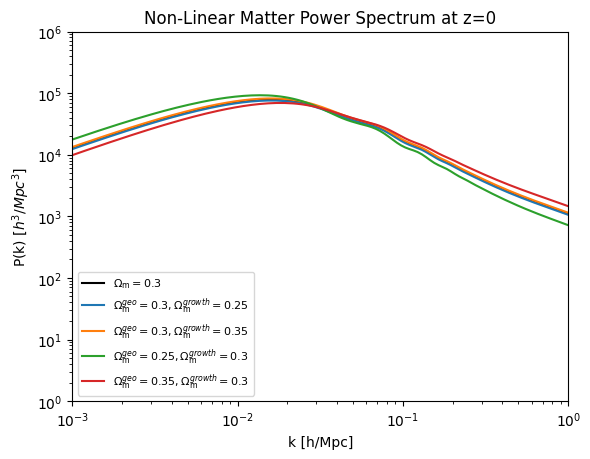

<Figure size 640x480 with 0 Axes>

In [11]:
# This can import the CosmoSIS pickles for the validation

# with open("mps_k_h.pkl", "rb") as in_pkl:
#     k_h = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-03_comp.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_03 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-03-om-growth-025_comp.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_025 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-03-om-growth-035_comp.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_035 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-025-om-growth-03_comp.pkl", "rb") as in_pkl:
#     mps_geo_025_gr_03 = pickle.load(in_pkl) / h ** 3
# with open("mps_om-geo-035-om-growth-03_comp.pkl", "rb") as in_pkl:
#     mps_geo_035_gr_03 = pickle.load(in_pkl) / h ** 3

plt.loglog(ks / h, nl_pk_3_3_interp(ks), color="black",
           label="$\\Omega_{\\rm m}=0.3$")
plt.loglog(ks / h, nl_pk_3_25_interp(ks),
           label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$")
plt.loglog(ks / h, nl_pk_3_35_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$")
plt.loglog(ks / h, nl_pk_25_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.3$")
plt.loglog(ks / h, nl_pk_35_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.3$")

# plt.plot(k_h, mps_geo_03_gr_03[0, :], label="$CS:\\Omega_{\\rm m}=0.3$",
#         color="grey", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_025[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3,\\Omega^{growth}_{\\rm m}=0.25$",
#         color="red", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_035[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3,\\Omega^{growth}_{\\rm m}=0.35$",
#         color="black", linestyle='--')
# plt.plot(k_h, mps_geo_025_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.3$",
#         color="orange", linestyle='--')
# plt.plot(k_h, mps_geo_035_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.3$",
#         color="purple", linestyle='--')

plt.xlabel("k [h/Mpc]")
plt.ylabel(r"P(k) [$h^3/Mpc^3$]")
plt.xlim(1e-3, 1e0)
plt.ylim(1e0, 1e6)
plt.title("Non-Linear Matter Power Spectrum at z=0")
plt.legend(fontsize=8)
plt.show()
plt.clf()

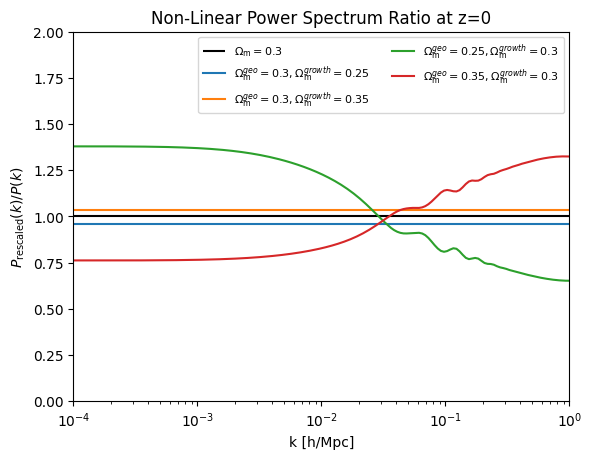

<Figure size 640x480 with 0 Axes>

In [12]:
# Plot the ratio of the rescaled and the standard MPS

plt.hlines(1, np.min(ks), np.max(ks), label="$\\Omega_{\\rm m}=0.3$",
           color="black")
plt.plot(ks / h, nl_pk_3_25_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$")
plt.plot(ks / h, nl_pk_3_35_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$")
plt.plot(ks / h, nl_pk_25_3_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.3$")
plt.plot(ks / h, nl_pk_35_3_interp(ks) / nl_pk_3_3_interp(ks),
    label="$\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.3$")

# plt.plot(k_h, mps_geo_03_gr_025[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$",
#         color="red", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_035[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$",
#         color="black", linestyle='--')
# plt.plot(k_h, mps_geo_025_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.3$",
#         color="orange", linestyle='--')
# plt.plot(k_h, mps_geo_035_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.3$",
#         color="purple", linestyle='--')

plt.title("Non-Linear Power Spectrum Ratio at z=0")
plt.xlabel("k [h/Mpc]")
plt.ylabel("$P_{\\rm rescaled}(k)/P(k)$")
plt.xscale("log")
plt.xlim(1e-4, 1e0)
plt.ylim(0, 2)
plt.legend(ncol=2, fontsize=8)
plt.show()
plt.clf()